In [1]:
 
import argparse
import importlib.util

import torch
import torch.nn as nn

def load_config(config_path):
    spec   = importlib.util.spec_from_file_location("cfg", config_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def get_args():
    parser = argparse.ArgumentParser()

    parser.add_argument("--config", type=str, default=None)
    parser.add_argument("--train", action="store_true")

    return parser.parse_args([]) 

args = get_args()

config_path = args.config or "config/Ex2.py"
cfg = load_config(config_path)

config = cfg.config
config["model_train"] = args.train

In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. toy dataset generator
# ============================================================
def build_toy_dataset(N_samples=100, M=128):
    x_ref = np.linspace(0, 1, M)

    X = []
    Y = []

    for _ in range(N_samples):
        # parameter: (3,)
        x = np.random.uniform(0, 1, size=(2,))
        a, b = x

        # 2-channel solution
        u = np.sin(2 * np.pi * x_ref * (1 + a)) + b
        v = np.cos(2 * np.pi * x_ref * (1 + b)) + a * b

        y = np.stack([u, v], axis=-1)  # (M,2)

        X.append(x)
        Y.append(y)

    X = np.stack(X, axis=0)  # (N,2)
    Y = np.stack(Y, axis=0)  # (N,M,2)

    return x_ref, X, Y


# ============================================================
# 2. dataset wrapper
# ============================================================
class ToyDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


# ============================================================
# 3. dataloader builder
# ============================================================
def get_dataloaders(config):
    """
    Returns:
        x_ref        : (M,)
        train_loader : DataLoader
        test_loader  : DataLoader
        param_names  : list[str]
    """

    # ------------------------------------------------------------
    # generate data
    # ------------------------------------------------------------
    x_ref, X, Y = build_toy_dataset(
        N_samples=100,
        M= 128
    )

    # ------------------------------------------------------------
    # train/test split
    # ------------------------------------------------------------
    n_train = int(config.get("train_ratio", 0.8) * len(X))

    X_train, Y_train = X[:n_train], Y[:n_train]
    X_test,  Y_test  = X[n_train:], Y[n_train:]

    # ------------------------------------------------------------
    # dataset
    # ------------------------------------------------------------
    train_dataset = ToyDataset(X_train, Y_train)
    test_dataset  = ToyDataset(X_test, Y_test)

    # ------------------------------------------------------------
    # dataloader
    # ------------------------------------------------------------
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.get("batch_size", 32),
        shuffle=True,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.get("batch_size", 32),
        shuffle=False
    )

    # ------------------------------------------------------------
    # parameter names
    # ------------------------------------------------------------
    param_names = ["a", "b", "c"]

    return x_ref, train_loader, test_loader, param_names

In [3]:

 
from libs.train_module    import trainer, setup_logger
from libs.evaluate_module import load_model, evaluate_model, plot_results_witherror


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device      : {device}")
print(f"Experiment  : {config['eq_name']}")
print(f"Mode        : {'train' if config['model_train'] else 'evaluate'}")

# ── data ──────────────────────────────────────────────────


x_ref, train_loader, val_loader, param_names = get_dataloaders(
    config
)

# quick shape check
for params_b, phi_b in train_loader:
    print(f"params batch: {params_b.shape}   "   # (B, P)
            f"phi batch: {phi_b.shape}")             # (B, N)
    break

logger = setup_logger(config["log_path"])

models = load_model(config, device)


Device      : cpu
Experiment  : Ex2
Mode        : evaluate
params batch: torch.Size([32, 2])   phi batch: torch.Size([32, 128, 2])


In [4]:
config

{'eq_name': 'Ex2',
 'model_train': False,
 'criterion': 'relative_l2',
 'hidden_dims': [128, 128, 128],
 'latent_feature_dim': 16,
 'n_latent': 64,
 'hidden_conv_dims': [256, 128, 128, 64, 64, 32, 32],
 'activation': torch.nn.modules.activation.ReLU,
 'output_activation': None,
 'learn_boundary': False,
 'complex_solution': True,
 'epochs': 2000,
 'epoch_save': 200,
 'batch_size': 32,
 'learning_rate': 0.001,
 'step_size': 1,
 'weight_decay': 1e-05,
 'gamma': 0.998,
 'input_dim': 2,
 'output_sol_dim': 2,
 'output_size': 128,
 'sol_name': './data/Ex2/solution.h5',
 'log_path': './logs/Ex2/train_2026-07-01_180536.log',
 'save_path': './result/Ex2/plot.png',
 'save_path_witherror': './result/Ex2/witherror.png',
 'model_save_path': './checkpoints/Ex2/best_model.pt',
 'error_save_path': './result/Ex2/RelL2.npz'}

In [5]:
config["epochs"] = 3

In [6]:
trainer(
      models       = models,
      train_loader = train_loader,
      val_loader  =  val_loader,
      config       = config,
      logger       = logger,
      device       = device,
  )

2026-07-01 18:05:37 | ============================================================
2026-07-01 18:05:37 | Experiment    : Ex2
2026-07-01 18:05:37 | criterion     : relative_l2
2026-07-01 18:05:37 | epochs        : 3
2026-07-01 18:05:37 | learning_rate : 0.001
2026-07-01 18:05:37 | weight_decay  : 1e-05
2026-07-01 18:05:37 | step_size     : 1
2026-07-01 18:05:37 | gamma         : 0.998
2026-07-01 18:05:37 | epoch_save    : 200
2026-07-01 18:05:37 | ============================================================
2026-07-01 18:05:42 | Epoch 00001 | train: 0.948289
2026-07-01 18:05:42 | Epoch 00001 | best saved (0.936463)
2026-07-01 18:05:43 | Epoch 00002 | train: 0.940753
2026-07-01 18:05:44 | Epoch 00002 | best saved (0.919055)
2026-07-01 18:05:45 | Epoch 00003 | train: 0.920268
2026-07-01 18:05:46 | Epoch 00003 | best saved (0.881665)
2026-07-01 18:05:46 | ============================================================
2026-07-01 18:05:46 | Training finished | best val: 0.881665
2026-07-01 18:

[LatentModel(
   (net): Sequential(
     (0): Linear(in_features=2, out_features=128, bias=True)
     (1): ReLU()
     (2): Linear(in_features=128, out_features=128, bias=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=128, bias=True)
     (5): ReLU()
     (6): Linear(in_features=128, out_features=1024, bias=True)
   )
 ),
 Decoder(
   (model): Sequential(
     (0): UpsampleBlock(
       (up): Upsample(scale_factor=2.0, mode='linear')
       (conv): Conv1d(16, 256, kernel_size=(3,), stride=(1,), padding=(1,))
       (act): LeakyReLU(negative_slope=0.2)
     )
     (1): UpsampleBlock(
       (up): Upsample(scale_factor=2.0, mode='linear')
       (conv): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
       (act): LeakyReLU(negative_slope=0.2)
     )
     (2): UpsampleBlock(
       (up): Upsample(scale_factor=2.0, mode='linear')
       (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
       (act): LeakyReLU(negative_slope=0.2)
   

2026-07-01 18:05:46 | Mean rel. L2 error : 0.8944 ± 0.0798
2026-07-01 18:05:46 | Max  rel. L2 error : 1.0801
2026-07-01 18:05:46 | Phi predict norm: 0.0662± 0.0395 
2026-07-01 18:05:46 | Phi true norm: 0.0662± 0.0395 
2026-07-01 18:05:46 | Phi error norm: 0.7292± 0.3047 
2026-07-01 18:05:46 | Phi error norm maximum: 1.6891
2026-07-01 18:05:46 | Results saved → ./result/Ex2/RelL2.npz
/Users/macos/Desktop/FinancialReportGPT/BEC/BEC1D/Code_BEC_foundry/libs/evaluate_module.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → ./result/Ex2/witherror.png


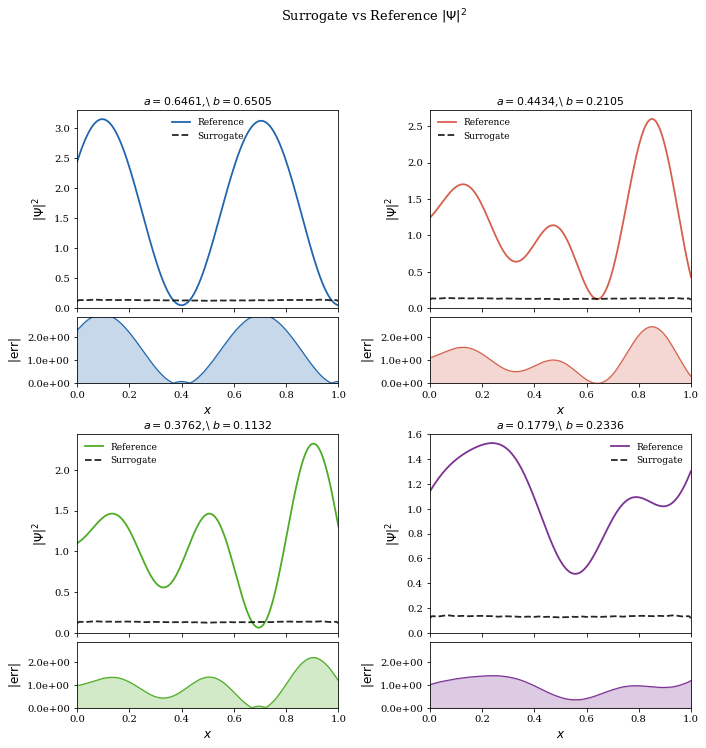

In [7]:

# ── evaluate ──────────────────────────────────────────────
params_all, phi_pred, phi_true, rel_errors = evaluate_model(
    x_ref, models, val_loader, 
    config["model_save_path"], 
    logger,  
    device, 
    learn_boundary=config["learn_boundary"],
    error_save_path=config["error_save_path"],
)


plot_results_witherror(
    x_ref, params_all, phi_pred, phi_true,
    complex = config["complex_solution"],
    param_names=param_names,
    save_path=config["save_path_witherror"],
)
